<a href="https://colab.research.google.com/github/helenova/thelook_ecommerce_analysis/blob/main/Stackoverflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
survey_results = pd.read_csv('/content/survey_results_public.csv')

In [ ]:
survey_results.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


1. Скільки респондентів пройшли опитування?

In [ ]:
print(survey_results.shape[0])

35130


2. Скільки респондентів відповіли на всі запитання?

In [ ]:
import pandas as pd
survey_results_sch = pd.read_csv('/content/survey_results_schema.csv')
survey_responses = pd.read_csv('/content/survey_results_public.csv')

questions_set = set(survey_results_sch['qname'].values)
responses_set = set(survey_responses.columns)

common_questions = questions_set.intersection(responses_set)
completed_responses = survey_responses.dropna(subset=common_questions)

count_completed = len(completed_responses)
print(count_completed)

6306


3. Які значення мір центральної тенденції для досвіду (WorkExp) респондентів?

In [ ]:
mean = survey_results['WorkExp'].mean(skipna=True)
median = survey_results['WorkExp'].median(skipna=True)
mode = survey_results['WorkExp'].mode(dropna=True)[0]

print(f'Mean (Середнє): {mean}')
print(f'Median (Медіана): {median}')
print(f'Mode (Мода): {mode}')

Mean (Середнє): 11.244960060859642
Median (Медіана): 9.0
Mode (Мода): 3.0


4. Скільки респондентів працює віддалено?

In [ ]:
remote_workers_count = survey_results[survey_results['RemoteWork'] == 'Remote'].shape[0]
print(f'Number of respondents working remotely: {remote_workers_count}')

Number of respondents working remotely: 11658


5. Який відсоток респондентів програмує на Python?

Percentage of respondents who program in Python: 50.52%


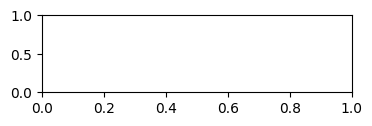

In [ ]:
python_developers = survey_results[survey_results['LanguageHaveWorkedWith'].str.contains('Python', case=False, na=False)]
python_count = python_developers.shape[0]
total_respondents = survey_results.shape[0]
percentage_python = (python_count / total_respondents) * 100

print(f"Percentage of respondents who program in Python: {percentage_python:.2f}%")

6. Скільки респондентів навчалося програмувати за допомогою онлайн курсів?

In [ ]:
online_respondents = survey_results[survey_results['LearnCode'].str.contains('Online course', case=False, na=False)]
online_count = online_respondents.shape[0]
total_respondents = survey_results.shape[0]
percentage_online = (online_count / total_respondents) * 100

print(f"Percentage of respondents who learn via online course: {percentage_online:.2f}%")

Percentage of respondents who learn via online course: 50.45%


7. Серед респондентів що програмують на Python в групуванні по країнам, яка середня та медіанна сума компенсації (ConvertedCompYearly) в кожній країні?

In [ ]:
result = python_developers.groupby('Country')['ConvertedCompYearly'].agg(
    mean_compensation='mean',
    median_compensation='median'
)
print(result)

                                      mean_compensation  median_compensation
Country                                                                     
Afghanistan                                 4543.000000               4768.5
Albania                                    56295.000000              56295.0
Algeria                                     9053.285714               6230.0
Andorra                                   193331.000000             193331.0
Angola                                         6.000000                  6.0
...                                                 ...                  ...
Venezuela, Bolivarian Republic of...        9511.111111               9600.0
Viet Nam                                   14454.964286              11555.5
Yemen                                      14647.500000              14647.5
Zambia                                     12541.500000              12541.5
Zimbabwe                                   30416.666667              17000.0

8. Які рівні освіти мають 5 респондентів з найбільшою компенсацією?

In [ ]:
top_5_compensation = survey_results.nlargest(5, 'ConvertedCompYearly')
top_5_education_levels = top_5_compensation['EdLevel']

print(top_5_education_levels)

15837      Bachelor’s degree (B.A., B.S., B.Eng., etc.)
12723    Professional degree (JD, MD, Ph.D, Ed.D, etc.)
28379    Professional degree (JD, MD, Ph.D, Ed.D, etc.)
17593      Bachelor’s degree (B.A., B.S., B.Eng., etc.)
17672    Professional degree (JD, MD, Ph.D, Ed.D, etc.)
Name: EdLevel, dtype: object


Бонусні запитання:

1. В кожній віковій категорії, який відсоток респондентів програмує на Python?

In [78]:
python_developers = survey_results[survey_results['LanguageHaveWorkedWith'].str.contains('Python', case=False, na=False)]
age_group_counts = survey_results['Age'].value_counts()
python_counts = python_developers['Age'].value_counts()
percentage_python_per_age = (python_counts / age_group_counts) * 100
print(percentage_python_per_age)


Age
18-24 years old       62.769565
25-34 years old       49.354442
35-44 years old       43.110505
45-54 years old       43.131548
55-64 years old       42.014388
65 years or older     40.047393
Prefer not to say     53.642384
Under 18 years old    70.459860
Name: count, dtype: float64


2. Серед респондентів що знаходяться в 75 перцентилі за компенсацією середнього і працюють віддалено, які індустрії є найрозповсюдженішими?

In [80]:
percentile_75 = survey_results['ConvertedCompYearly'].quantile(0.75)
filtered_respondents = survey_results[
    (survey_results['ConvertedCompYearly'] >= percentile_75) &
    (survey_results['RemoteWork'] == 'Remote')
]
industry_counts = filtered_respondents['DevType'].value_counts()
industry_counts


,count
DevType,
"Developer, full-stack",891
"Developer, back-end",600
Engineering manager,135
"Developer, front-end",126
Other (please specify):,106
"Developer, desktop or enterprise applications",91
Data engineer,80
"Developer, mobile",76
"Senior Executive (C-Suite, VP, etc.)",69
